In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Nassau Candy Distributor.csv")
df.head

<bound method NDFrame.head of        Row ID                      Order ID  Order Date   Ship Date  \
0           1  US-2021-103800-CHO-MIL-31000  03-01-2024  30-06-2026   
1           2  US-2021-112326-CHO-TRI-54000  04-01-2024  01-07-2026   
2           3  US-2021-112326-CHO-NUT-13000  04-01-2024  01-07-2026   
3           4  US-2021-112326-CHO-SCR-58000  04-01-2024  01-07-2026   
4           5  US-2021-141817-CHO-TRI-54000  05-01-2024  05-07-2026   
...       ...                           ...         ...         ...   
10189   10190  US-2024-143259-CHO-MIL-31000  30-12-2025  26-06-2030   
10190   10191  US-2024-115427-CHO-NUT-13000  30-12-2025  26-06-2030   
10191   10192  US-2024-156720-CHO-SCR-58000  30-12-2025  26-06-2030   
10192   10193  US-2024-143259-CHO-TRI-54000  30-12-2025  26-06-2030   
10193   10194  CA-2024-143500-CHO-SCR-58000  30-12-2025  26-06-2030   

            Ship Mode  Customer ID Country/Region           City  \
0      Standard Class       103800  United States

In [6]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Country/Region', 'City', 'State/Province',
       'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name',
       'Sales', 'Units', 'Gross Profit', 'Cost'],
      dtype='object')

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Row ID,10194.0,5097.500000,2942.898656,1.00,2549.25,5097.50,7645.75,10194.0
Customer ID,10194.0,134468.961154,20231.483007,100006.00,117212.00,133550.00,152051.00,192314.0
Sales,10194.0,13.908537,11.341020,1.25,7.20,10.80,18.00,260.0
Units,10194.0,3.791838,2.228317,1.00,2.00,3.00,5.00,14.0
Gross Profit,10194.0,9.166451,6.643740,0.25,4.90,7.47,12.25,130.0
Cost,10194.0,4.742087,5.061647,0.60,2.40,3.60,5.70,130.0


In [11]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Division        10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null 

In [15]:
df.duplicated().sum()

np.int64(0)

In [ ]:
**FACTORY-TO-CUSTOMER SHIPPING ROUTE EFFICIENCY ANALYSIS

**Nassau Candy Distributor


Research paper: exploratory analysis, route benchmarking, bottleneck diagnosis, and operational recommendations

Dataset: 10,194 order-product rows | 8,549 unique shipments | Analysis threshold: > 5 days


Analytical project report • Prepared from supplied dataset

NASSAU CANDY DISTRIBUTOR  |  ROUTE EFFICIENCY

**Executive Summary

The analysis converts 10,194 order-product records into 8,549 unique factory-to-customer shipment legs. After correcting a systematic date-offset anomaly, the network averages 4.29 days, with a 24.6% delay frequency at the default threshold of more than 5 days.

Same Day is fastest at 0.38 days; First Class averages 2.55, Second Class 3.54, and Standard Class 5.32 days.

Standard Class carries 5,142 shipments (60.1% of shipment legs) and contributes most delay exposure, with a 38.8% delay rate under the global five-day threshold.

The highest-priority high-volume state bottlenecks are Tennessee, Illinois, Washington, and Arizona.

Regional averages are close (4.26–4.38 days), suggesting bottlenecks are more route- and state-specific than region-wide.

Freight cost is absent. The Cost field is manufacturing cost, so a valid speed-versus-freight-cost optimization cannot yet be performed.

1. Background and Objectives

Shipping reliability affects customer satisfaction, operating cost, and the ability to scale a national distribution network. The project measures performance at factory-to-state and factory-to-region levels, compares ship modes, identifies geographic bottlenecks, and supplies a reproducible dashboard for operational monitoring.

** Research questions

Which routes are consistently fastest and most reliable?

Which routes have the highest average lead time, variability, and delay frequency?

How do customer region, state/province, and ship mode influence performance?

Where do high shipment volume and weak lead-time performance coincide?

**2. Data and Validation

Validation item                                                Result
Source rows                                                    10,194
Unique Order IDs                                                8,549
Valid analytical rows                                          10,194
Date parse failures                                                 0
Unmapped products/factories                                         0
Negative corrected lead times                                       0

**Critical date anomaly and correction

Raw Ship Date minus Order Date averages 1320.8 days and ranges from 904 to 1,642 days, which is operationally implausible.
The differences form stable Order ID year cohorts.
The analysis therefore retains Raw Lead Time for audit and defines Operational Lead Time as raw lead time minus the minimum raw lead time within each Order ID year cohort.
Offsets: 2021=904 days; 2022=1269 days; 2023=1269 days; 2024=1634 days. The corrected range is 0–11 days and produces the expected ship-mode sequence.
This transformation is an analytical normalization, not proof of the original dates.
Source-system owners should replace the dates with verified timestamps before contractual SLA reporting.

3. Feature Engineering and KPI Definitions

KPI                                                             Operational definition 
Shipment leg                                       One unique Order ID × Factory × customer destination
Operational lead time                                    Corrected shipment duration in days
Route volume                                              Distinct shipment legs on a route
Delay frequency                                          Share of shipment legs above 5 days
Variability                                            Standard deviation of corrected lead time
Efficiency score                         50% inverse average lead + 25% inverse variability + 25% inverse delay frequency
Ranking rule                                             Routes with at least 5 shipment legs

The five-shipment minimum reduces unstable rankings from one-off routes. Scores are comparative within this dataset and should not be treated
as contractual service levels.

4. Network-Level Findings

KPI                                                       Result
Shipment legs                                             8,549
Average lead time                                         4.29 days
Median lead time                                          4.0 days
Delay threshold                                         > 5 days
Delay frequency                                           24.6%
Sales                                                     $141,783.63
Gross profit                                              $93,442.80

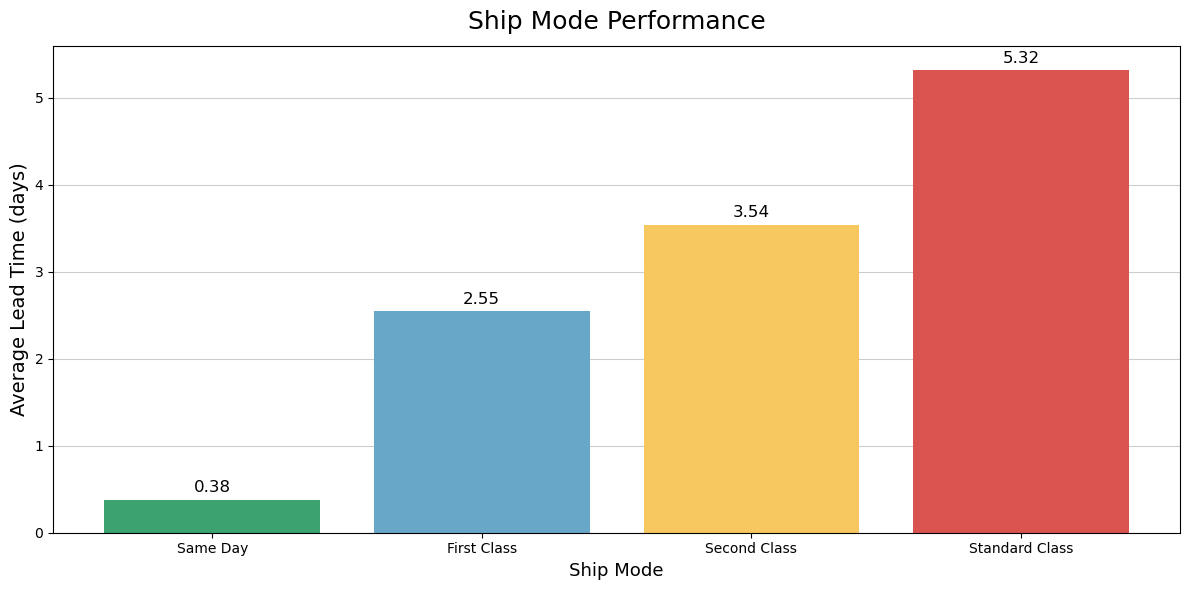

In [2]:
### 5. Ship Mode Performance--

import matplotlib.pyplot as plt

# Data
ship_modes = [
    "Same Day",
    "First Class",
    "Second Class",
    "Standard Class"
]

average_lead_time = [0.38, 2.55, 3.54, 5.32]

colors = [
    "#3CA370",  # Green
    "#68A7C8",  # Blue
    "#F6C85F",  # Yellow
    "#D9534F"   # Red
]

# Create chart
plt.figure(figsize=(12, 6))

bars = plt.bar(
    ship_modes,
    average_lead_time,
    color=colors
)

# Add values above bars
for bar, value in zip(bars, average_lead_time):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=12
    )

plt.title("Ship Mode Performance", fontsize=18, pad=12)
plt.xlabel("Ship Mode", fontsize=13)
plt.ylabel("Average Lead Time (days)", fontsize=14)

plt.ylim(0, 5.6)
plt.grid(axis="y", color="#cccccc", linewidth=0.8)
plt.gca().set_axisbelow(True)

plt.tight_layout()

# Save the chart
plt.savefig(
    "ship_mode_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
Ship mode                    Shipments                              Avg days                         Std. dev.                   Delay rate
Same Day                       442                                   0.38                              0.53                         0.0%
First Class                   1,312                                  2.55                              0.88                         0.0%
Second Class                  1,653                                  3.54                              1.26                         6.7%
Standard Class                5,142                                  5.32                              1.12                        38.8%

Interpretation:
The operational ranking is coherent, but mode selection may reflect urgency or customer characteristics.
The analysis is descriptive and does not claim that changing mode alone causes the observed improvement.
A freight-cost field is required for economic optimization.

In [ ]:
6. Route Efficiency Leaderboard

**Top 10 eligible routes

Route                              N                                   Avg days                      Delay                                   Score
Wicked Choccy's → Vermont           5                                    3.60                          0.0%                                    92.2
Lot's O' Nuts → Ontario            24                                    3.33                          0.0%                                    91.4
Wicked Choccy's → Ontario          17                                    3.59                          0.0%                                    90.5
The Other Factory → Texas           9                                    3.67                          0.0%                                    90.3
Wicked Choccy's → Nova Scotia       6                                    3.67                          0.0%                                    89.9
Lot's O' Nuts → New Hampshire      13                                    3.46                          0.0%                                    89.3
Wicked Choccy's → Louisiana        14                                    3.29                          7.1%                                    87.5
Lot's O' Nuts → Nebraska           20                                    3.45                          0.0%                                    86.8
Wicked Choccy's → Manitoba          6                                    3.83                          0.0%                                    86.4
Lot's O' Nuts → Montana             7                                    4.57                          0.0%                                    84.2

In [ ]:
 ** Bottom 10 eligible routes

Route                                          N                        Avg days                             Delay                             Score
Lot's O' Nuts → Newfoundland and Labrador      5                         7.40                                80.0%                              6.1
Lot's O' Nuts → South Dakota                   6                         5.50                                66.7%                             44.8
Wicked Choccy's → Montana                      5                         4.60                                40.0%                             46.5
Lot's O' Nuts → Arkansas                      25                         4.88                                48.0%                             47.8
Lot's O' Nuts → District of Columbia           6                         5.67                                66.7%                             50.2
The Other Factory → New York                  13                         4.77                                46.2%                             51.4
Wicked Choccy's → Minnesota                   36                         5.00                                38.9%                             52.3
Lot's O' Nuts → New Mexico                    18                         5.44                                44.4%                             52.7
Lot's O' Nuts → Nevada                        23                         4.61                                43.5%                             53.5
Lot's O' Nuts → Iowa                          14                         4.79                                42.9%                             54.3

The lowest score belongs to Lot's O' Nuts → Newfoundland and Labrador (7.40 days; 80.0% delayed; n=5).
Because several extremes have small sample sizes,
operational action should prioritize both performance and volume.

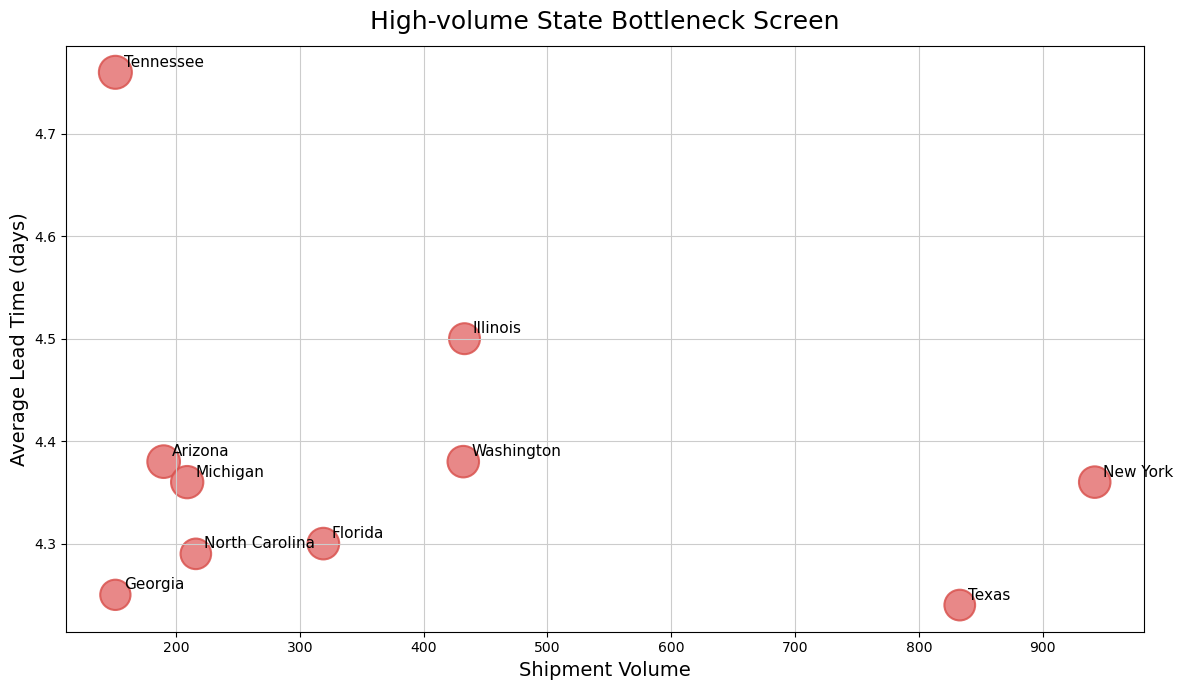

In [1]:
### 7. Geographic Bottleneck Analysis

import pandas as pd
import matplotlib.pyplot as plt

# High-volume state data
data = {
    "State": [
        "Tennessee", "Illinois", "Washington", "Arizona",
        "Michigan", "Florida", "North Carolina",
        "Georgia", "Texas", "New York"
    ],
    "Shipment Volume": [
        151, 433, 432, 190,
        209, 319, 216,
        151, 833, 942
    ],
    "Average Lead Time": [
        4.76, 4.50, 4.38, 4.38,
        4.36, 4.30, 4.29,
        4.25, 4.24, 4.36
    ],
    "Delay Rate": [
        0.331, 0.245, 0.269, 0.316,
        0.301, 0.273, 0.231,
        0.219, 0.236, 0.269
    ]
}

df = pd.DataFrame(data)

# Bubble size represents delay rate
bubble_size = 300 + (df["Delay Rate"] * 800)

plt.figure(figsize=(12, 7))

plt.scatter(
    df["Shipment Volume"],
    df["Average Lead Time"],
    s=bubble_size,
    color="#e57373",
    edgecolor="#d9534f",
    linewidth=1.5,
    alpha=0.85
)

# Add state labels
for _, row in df.iterrows():
    plt.annotate(
        row["State"],
        (row["Shipment Volume"], row["Average Lead Time"]),
        xytext=(6, 4),
        textcoords="offset points",
        fontsize=11
    )

plt.title(
    "High-volume State Bottleneck Screen",
    fontsize=18,
    pad=12
)

plt.xlabel("Shipment Volume", fontsize=14)
plt.ylabel("Average Lead Time (days)", fontsize=14)

plt.grid(
    True,
    linestyle="-",
    linewidth=0.8,
    color="#cccccc"
)

plt.tight_layout()

# Save image
plt.savefig(
    "high_volume_state_bottleneck.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



In [ ]:
State                                 Region                              Shipments                     Avg days                             Delay rate
Tennessee                            Gulf                                  151                          4.76                                  33.1%
Illinois                             Interior                              433                          4.50                                  24.5%
Washington                           Pacific                               432                          4.38                                  26.9%
Arizona                              Pacific                               190                          4.38                                  31.6%

Tennessee combines the weakest lead time among the high-volume screen with a 33.1% delay rate.
Illinois and Washington carry much larger volumes, so modest improvements there may produce the greatest absolute reduction in delayed shipments.
Arizona has both elevated average lead time and a 31.6% delay rate.

In [ ]:
** Regional comparison

Region                             Shipments                           Avg days                          Variability                    Delay rate
Atlantic                             2,476                              4.26                                 1.79                          23.5%
Gulf                                 1,350                              4.29                                 1.77                          24.0%
Interior                             1,979                              4.38                                 1.73                          25.5%
Pacific                              2,744                              4.27                                 1.83                          25.2%

In [ ]:
8. Recommendations

1. Correct the source timestamps

Verify Order Date and Ship Date in the operational system; retain the cohort correction only as a temporary analytical bridge.

2. Focus on high-volume bottlenecks

Start weekly exception reviews for Tennessee, Illinois, Washington, and Arizona, segmented by factory and ship mode.

3. Control Standard Class exposure

Analyze Standard Class routes above five days and test targeted upgrades only for high-value or service-critical orders.

4. Introduce route control limits

Track average lead, 90th percentile, variability, delay rate, and shipment volume with a minimum sample-size rule.

5. Add missing logistics fields

Capture promised delivery date, actual delivery date, carrier, freight charge, distance, warehouse processing time, and exception reason.

6. Use staged pilots

Pilot changes on one high-volume route for four to eight weeks, compare pre/post results, then scale only measured improvements.

In [ ]:
9. Dashboard Design

The companion Streamlit application includes date, region, state/province,
ship-mode, and delay-threshold filters; route leaderboard; US state choropleth; ship-mode comparison;
state table; and order-level route drill-down.
Rankings recalculate after filtering and retain the five-shipment eligibility rule.

In [ ]:
10. Limitations

1.Corrected lead time depends on an inferred cohort offset and must be validated against source data.

2.No promised-date field exists, so “delay” is a benchmark exception rather than a contractual late delivery.

3.No actual delivery timestamp is available; Ship Date may represent dispatch rather than customer receipt.

4.Manufacturing Cost cannot substitute for freight cost.

5.Customer geography includes Canadian provinces although the brief emphasizes the United States.

6.Findings are descriptive; route and mode differences may reflect product mix, urgency, seasonality, or customer selection.

In [ ]:
11. Conclusion

The corrected dataset shows a generally consistent network average near 4.3 days, but meaningful route-level differences remain.
Standard Class is the main source of delay exposure, while Tennessee,Illinois, Washington, and Arizona are the most actionable high-volume bottlenecks.
The strongest next step is to repair timestamp quality, add promised-delivery and freight-cost fields,and use the dashboard for controlled,
route-specific improvement.

In [ ]:
Appendix: Reproducibility

All metrics are generated from the supplied CSV using the documented product-to-factory mapping.
The accompanying workbook contains route, mode, geography, and shipment-leg tables.
The Streamlit application reads the generated shipment-leg file and recalculates filtered metrics interactively

In [ ]:
Purpose: provide decision-makers with an auditable view of factory-to-customer route efficiency and immediate operational priorities.

Network indicator                                                                        Current result                                      
Shipment legs                                                                                8,549
Average / median lead time                                                              4.29 / 4.0 days
Delay frequency                                                                         24.6% (>5 days)
Highest-volume mode                                                               Standard Class: 5,142 shipments
Standard Class delay rate                                                                      38.8%

In [ ]:
What requires attention

Source dates contain systematic offsets. Corrected lead time is suitable for comparative analysis but not contractual reporting until timestamps are verified.
Prioritize Tennessee, Illinois, Washington, and Arizona because they combine high shipment volume with above-median lead time.
Review the weakest eligible route, Lot's O' Nuts → Newfoundland and Labrador, but treat it cautiously because it has only five shipments.

In [ ]:
## Recommended 90-day action plan

Timing                                       Action                                                                     Success measure
Days 0–30               Validate source timestamps and define promised-delivery SLA                 Verified date dictionary and signed KPI definitions
Days 31–60                  Pilot exception management on four bottleneck states                         Lower delayed shipment count versus baseline
Days 61–90       Review Standard Class route rules; add freight cost and carrier fields              Documented routing policy and cost-aware dashboard

In [ ]:
    Shipments                                     Avg lead time                                   Delay frequency              Gross profit   
     8549                                            4.29 Days                                       24.6%                  93442.80000000237

In [ ]:
Top routes	                         Shipments	                           Avg days	                          Delay rate	                 Score
Wicked Choccy's → Vermont	             5	                                  3.6	                               0	                     92.184
Lot's O' Nuts → Ontario		             24                                   3.333	                               0                         91.411
Wicked Choccy's → Ontario	             17	                                  3.588	                               0	                     90.533
The Other Factory → Texas	             9	                                  3.667	                               0	                     90.257
Wicked Choccy's → Nova Scotia	         6	                                  3.667	                               0	                     89.911
Lot's O' Nuts → New Hampshire	         13	                                  3.462	                               0                         89.26
Wicked Choccy's → Louisiana	             14	                                  3.286                            	 0.071	                     87.475
Lot's O' Nuts → Nebraska	             20	                                  3.45	                               0	                     86.843
Wicked Choccy's → Manitoba	              6	                                  3.833	                               0                         86.445
Lot's O' Nuts → Montana                	  7                                   4.571	                               0	                     84.183

In [ ]:
Bottom routes	                       Shipments	                             Avg days	                       Delay rate	                 Score
Lot's O' Nuts → Newfoundland and Labrador	5	                                   7.4	                               0.8	                     6.119
Lot's O' Nuts → South Dakota	            6	                                   5.5	                               0.667	                44.768
Wicked Choccy's → Montana	                5	                                   4.6	                               0.4	                    46.528 
Lot's O' Nuts → Arkansas	               25	                                   4.88	                               0.48	                    47.777
Lot's O' Nuts → District of Columbia	    6	                                   5.667	                           0.667	                50.231
The Other Factory → New York	           13	                                   4.769	                           0.462	                51.36
Wicked Choccy's → Minnesota	               36	                                   5	                               0.389	                52.255
Lot's O' Nuts → New Mexico	               18	                                   5.444	                           0.444	                52.658
Lot's O' Nuts → Nevada	                   23	                                   4.609	                           0.435	                53.54
Lot's O' Nuts → Iowa                       14	                                   4.786	                           0.429	                54.308
				

In [ ]:
              Ship mode	                                                                          Avg lead days
              Same Day	                                                                        0.3778280542986425
              First Class	                                                                    2.5541158536585367
              Second Class	                                                                    3.540834845735027
              Standard Class	                                                                5.3179696616102685

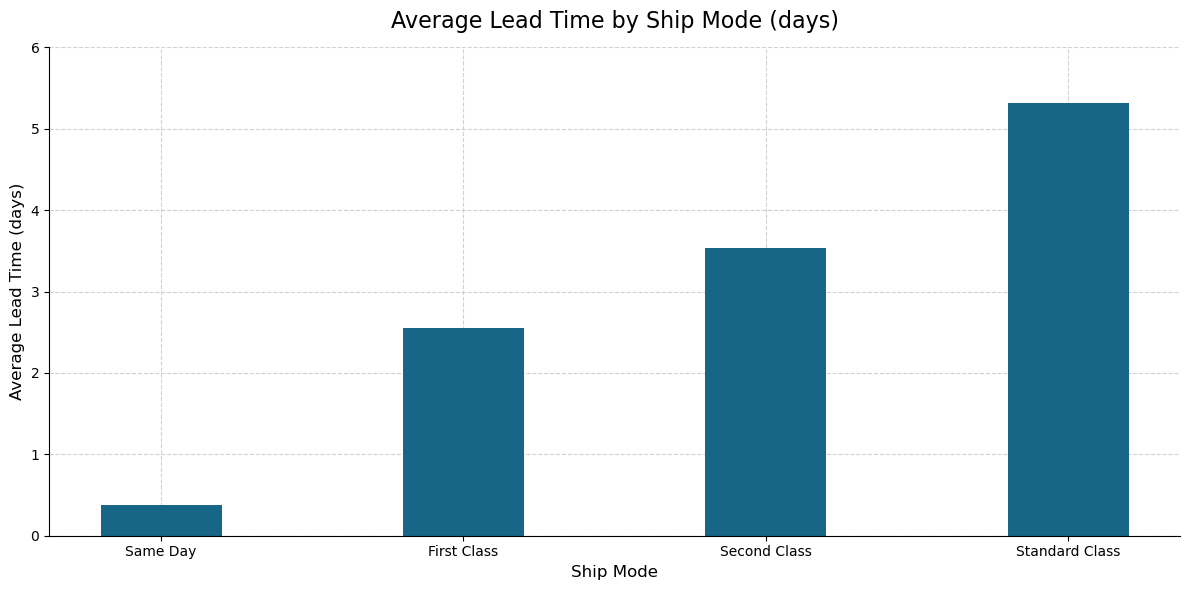

In [3]:
import matplotlib.pyplot as plt

# Ship mode performance data
ship_modes = [
    "Same Day",
    "First Class",
    "Second Class",
    "Standard Class"
]

average_lead_time = [0.38, 2.55, 3.54, 5.32]

# Create the chart
plt.figure(figsize=(12, 6))

bars = plt.bar(
    ship_modes,
    average_lead_time,
    width=0.40,
    color="#176687"
)

plt.title(
    "Average Lead Time by Ship Mode (days)",
    fontsize=16,
    pad=14
)

plt.xlabel("Ship Mode", fontsize=12)
plt.ylabel("Average Lead Time (days)", fontsize=12)

plt.ylim(0, 6)

# Dashed gridlines like the Excel chart
plt.grid(
    axis="both",
    linestyle="--",
    linewidth=0.8,
    color="#cccccc",
    alpha=0.9
)

plt.gca().set_axisbelow(True)

# Remove unnecessary borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

# Save chart
plt.savefig(
    "average_lead_time_by_ship_mode.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()